# AQUASPECT — Proof of Concept
**Arab Youth Space Hackathon 813 · Theme 6: Water Quality & Inland/Coastal Water Intelligence**

> **Validation note:** No concurrent in-situ measurements are available for these scenes.
> All indices are dimensionless proxies. Anomalies are statistical deviations from a
> 12-month historical baseline — not confirmed pollution or algal bloom events.

---


## Setup
Run this cell first. If you are on **Google Colab**, mount your Drive and set `PROJECT_ROOT`
to wherever you uploaded the AQUASPECT folder (e.g. `/content/drive/MyDrive/AQUASPECT`).


In [ ]:
import os, sys, warnings
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
warnings.filterwarnings('ignore')

# Mount Google Drive (run this on Colab before the rest):
# from google.colab import drive; drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/AQUASPECT"  # <- Google Drive path

import pathlib
PROJECT_ROOT  = pathlib.Path(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from aquaspect import preprocessing, indices, detection

DATA_DIR     = PROJECT_ROOT / "data" / "sample_input"
RESULTS_MAPS = PROJECT_ROOT / "results" / "maps"
RESULTS_FIGS = PROJECT_ROOT / "results" / "figures"
RESULTS_TBLS = PROJECT_ROOT / "results" / "tables"

print("Project root:", PROJECT_ROOT)
print("Maps dir exists:", RESULTS_MAPS.exists())
print("Figures dir exists:", RESULTS_FIGS.exists())


In [2]:
def show_map(path, title="", figsize=(12, 8)):
    img = mpimg.imread(str(path))
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()


---
## Part 1 — El Gouna Hyperspectral Analysis (Planet Tanager)
**Scene:** `20250926_092059_95_4001` · **Date:** 2025-09-26  
**Sensor:** Planet Tanager · **Bands:** 426 · **Range:** 376–2499 nm · **GSD:** ~33 m


In [3]:
TANAGER_FILE = DATA_DIR / "20250926_092059_95_4001_ortho_sr_hdf5.h5"

valid_mask, qa_stats = preprocessing.build_qa_mask(str(TANAGER_FILE))
print("QA Statistics:")
for k, v in qa_stats.items():
    print(f"  {k}: {v}")

with h5py.File(TANAGER_FILE, "r") as f:
    sr          = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"]
    wavelengths = sr.attrs["wavelengths"][:]
    print(f"\nArray shape : {sr.shape}")
    print(f"Wavelength  : {wavelengths[0]:.1f} – {wavelengths[-1]:.1f} nm")

    target_nms = [443, 560, 665, 708, 800, 860]
    band_idx   = {t: int(np.argmin(np.abs(wavelengths - t))) for t in target_nms}
    for t, i in band_idx.items():
        print(f"  {t} nm  ->  {wavelengths[i]:.1f} nm  (band {i})")

    def load_b(nm):
        arr = sr[band_idx[nm], :, :].astype(np.float32) * 1e-4
        arr[~valid_mask] = np.nan
        arr[(arr < 0) | (arr > 1)] = np.nan
        return arr

    b_green, b_red, b_rededge, b_nir2 = (
        load_b(560), load_b(665), load_b(708), load_b(860)
    )

ndwi_arr = indices.ndwi(b_green, b_nir2)
wm_raw   = indices.water_mask(ndwi_arr, threshold=0.0)
water_mask, ws = detection.apply_water_mask(wm_raw & valid_mask,
                                             min_pixels=100, pixel_area_m2=900)
print(f"\nWater area   : {ws['estimated_area_km2']:.2f} km²")
print(f"Water pixels : {ws['retained_water_pixels']:,}")

ndci_arr = indices.ndci(b_rededge, b_red)
turb_arr = indices.turbidity_proxy(b_red, b_green)
tv = turb_arr[water_mask]; tv = tv[~np.isnan(tv)]
print(f"Turbidity proxy (dimensionless): mean={np.mean(tv):.4f}  max={np.max(tv):.4f}")


QA Statistics:
  total_pixels: 687564
  valid_pixels: 448045
  invalid_pixels: 239519
  valid_pct: 65.16
  nodata_pct: 28.88
  cloud_pct: 5.96
  cirrus_pct: 0.0

Array shape : (426, 852, 807)
Wavelength  : 376.4 – 2499.0 nm
  443 nm  ->  441.1 nm  (band 13)
  560 nm  ->  560.8 nm  (band 37)
  665 nm  ->  665.9 nm  (band 58)
  708 nm  ->  705.9 nm  (band 66)
  800 nm  ->  801.1 nm  (band 85)
  860 nm  ->  861.3 nm  (band 97)



Water area   : 212.37 km²
Water pixels : 235,965
Turbidity proxy (dimensionless): mean=-0.1964  max=0.0502


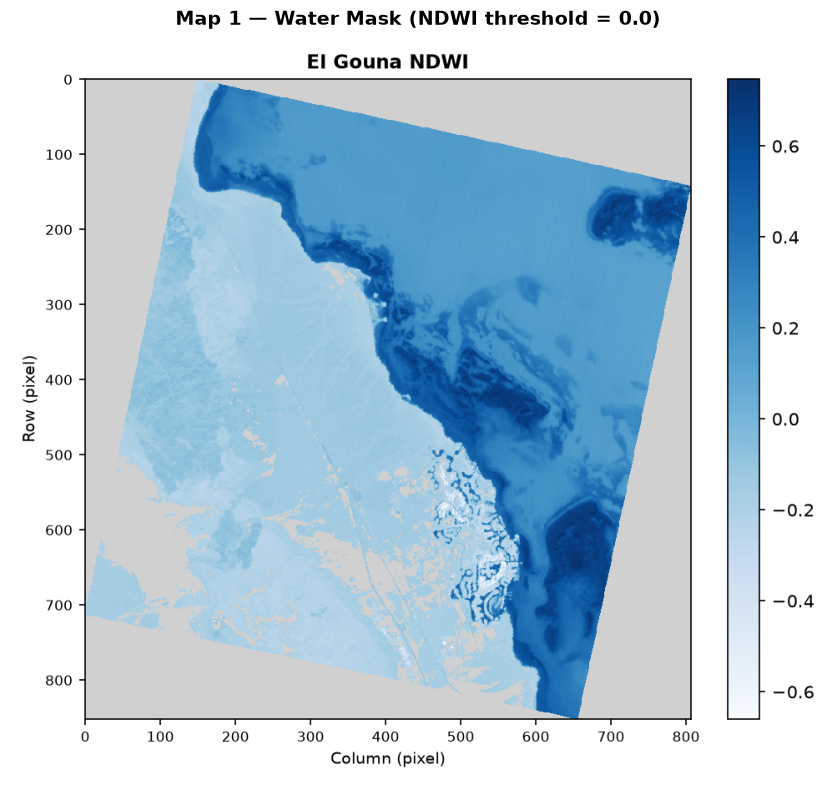

In [4]:
show_map(RESULTS_MAPS / "elgouna_water_mask.png",
         "Map 1 — Water Mask (NDWI threshold = 0.0)")


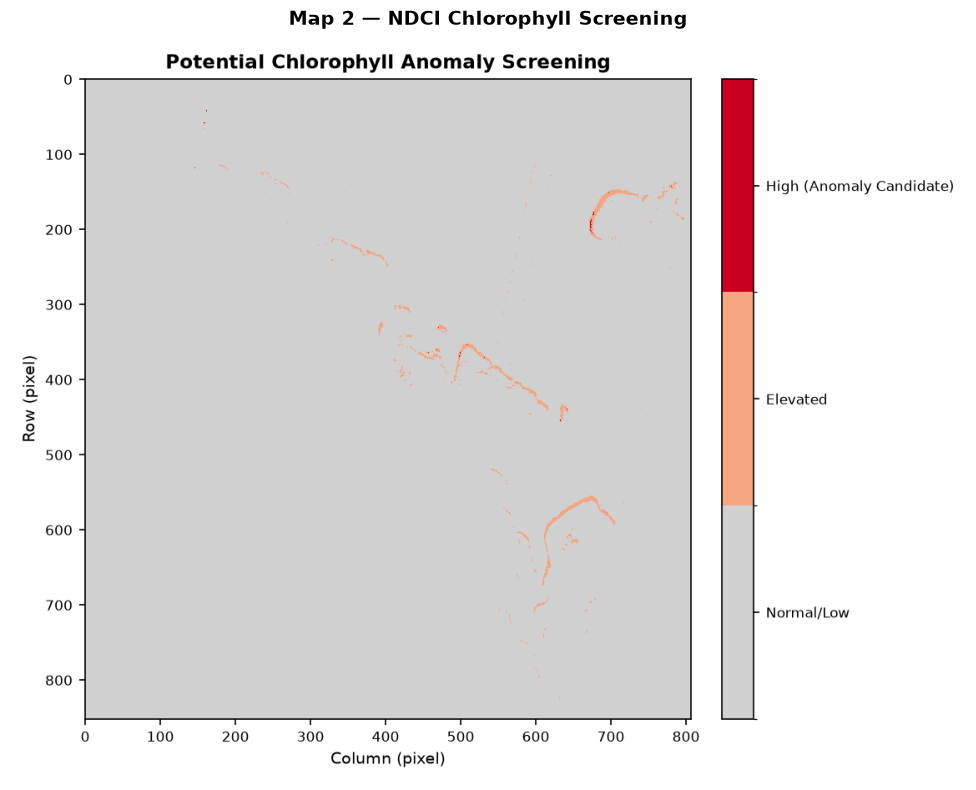

In [5]:
show_map(RESULTS_MAPS / "elgouna_chlorophyll_screening.png",
         "Map 2 — NDCI Chlorophyll Screening")


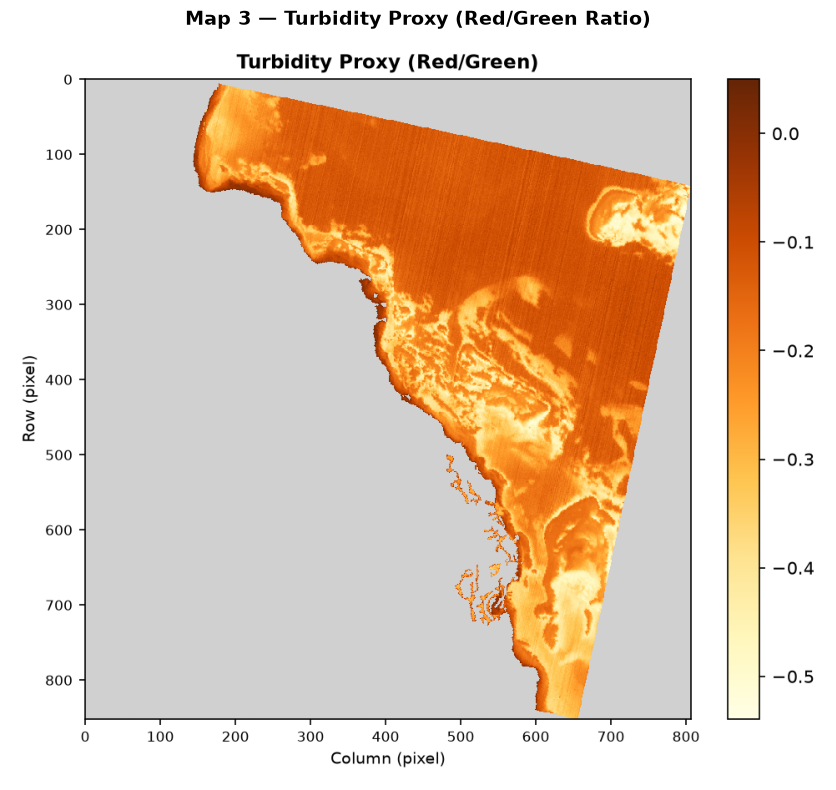

In [6]:
show_map(RESULTS_MAPS / "elgouna_turbidity_proxy.png",
         "Map 3 — Turbidity Proxy (Red/Green Ratio)")


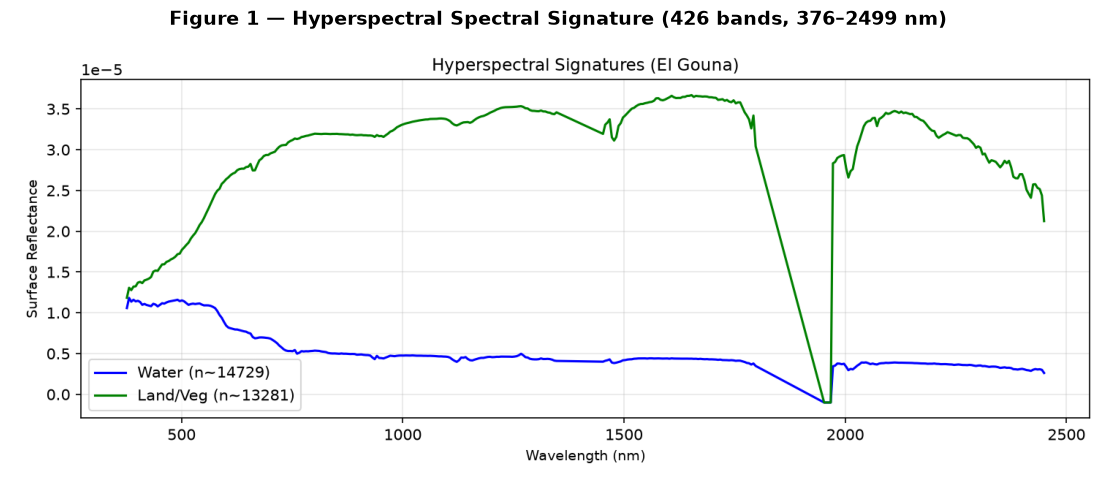

In [7]:
show_map(RESULTS_FIGS / "elgouna_hyperspectral_signature.png",
         "Figure 1 — Hyperspectral Spectral Signature (426 bands, 376–2499 nm)", figsize=(14, 5))


---
## Part 2 — Lake Manzala Temporal Baseline (Sentinel-2 L2A)
8 distinct scenes · June 2024 – May 2025 · Turbidity proxy Z-score anomaly detection


In [8]:
s2_metrics = pd.read_csv(RESULTS_TBLS / "manzala_temporal_metrics.csv")
print("12-Month Scene Table:")
display(s2_metrics)


12-Month Scene Table:


,date,item_id,tile,cloud_pct,water_pixels,water_area_km2,mean_ndwi,mean_turbidity,std_turbidity,mean_ndci
0,2024-06-06,S2A_MSIL2A_20240606T082611_R021_T36RUV_2024060...,T36RUV,0.000000,41889,418.89,0.14243,-0.07308,0.02258,-0.07009
1,2024-07-21,S2B_MSIL2A_20240721T082609_R021_T36RTV_2024072...,T36RTV,0.000000,19329,193.29,0.19200,-0.08403,0.03286,-0.10989
2,2024-08-20,S2B_MSIL2A_20240820T082559_R021_T36RTV_2024082...,T36RTV,0.000000,20143,201.43,0.16559,-0.10158,0.03253,-0.06524
3,2024-09-27,S2A_MSIL2A_20240927T083731_R064_T36RUV_2024092...,T36RUV,0.000000,28252,282.52,0.15115,-0.10158,0.02791,-0.05055
4,2024-10-04,S2A_MSIL2A_20241004T082811_R021_T36RVV_2024100...,T36RVV,5.940000,410013,4100.13,0.16083,-0.10437,0.01991,-0.05745
5,2024-12-28,S2B_MSIL2A_20241228T083259_R021_T36RVV_2024122...,20241228T093822,0.053533,466347,4663.47,0.16411,-0.09021,0.02347,-0.07498
6,2025-01-30,S2B_MSIL2A_20250130T084119_R064_T36RUV_2025013...,20250130T124050,0.027967,48003,480.03,0.16823,-0.08750,0.02041,-0.08204
7,2025-04-27,S2A_MSIL2A_20250427T084501_R064_T36RTV_2025042...,T36RTV,3.970000,41281,412.81,0.14999,-0.07901,0.03411,-0.07193


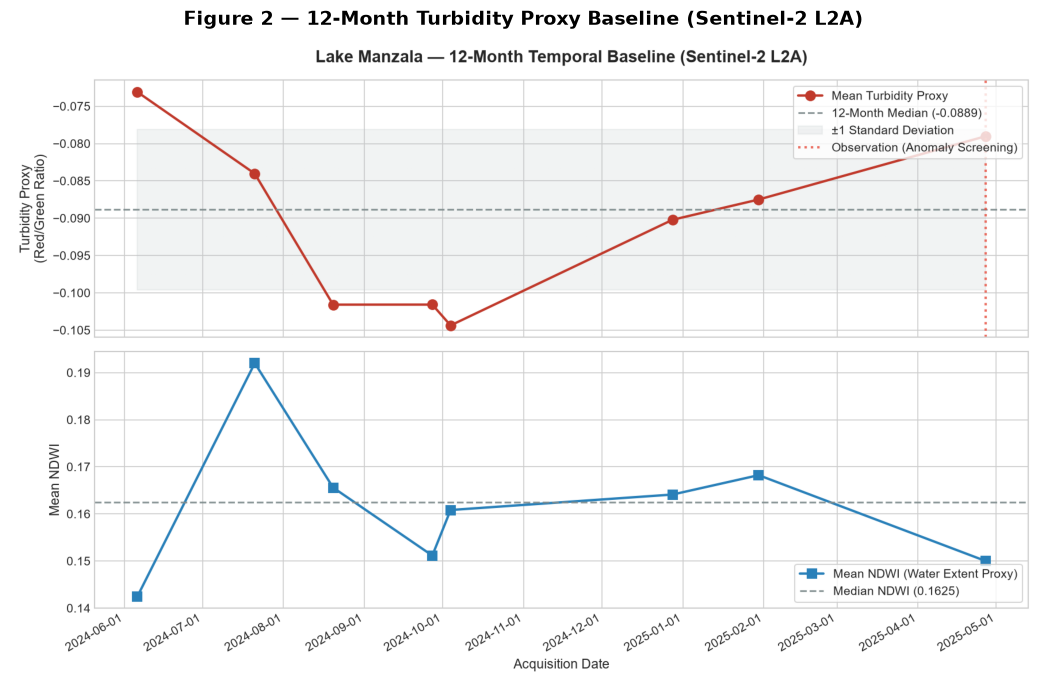

In [9]:
show_map(RESULTS_FIGS / "manzala_temporal_baseline.png",
         "Figure 2 — 12-Month Turbidity Proxy Baseline (Sentinel-2 L2A)", figsize=(14, 7))


In [10]:
anomaly = pd.read_csv(RESULTS_TBLS / "manzala_anomaly_summary.csv")
total_water = s2_metrics.iloc[-1]['water_pixels']
extreme_px  = anomaly.iloc[0]['anomaly_extreme_px']

print("Anomaly Detection Results (Z-Score method):")
display(anomaly)

print(f"\nOn {anomaly.iloc[0]['reference_date']}:")
print(f"  {extreme_px:,} pixels ({extreme_px/total_water:.1%}) exceed Z = 3.0 vs 12-month baseline.")
print("  => Statistically extreme deviation. Requires field verification.")


Anomaly Detection Results (Z-Score method):


,reference_date,anomaly_normal_px,anomaly_elevated_px,anomaly_high_px,anomaly_extreme_px,z_threshold_elevated,z_threshold_high,z_threshold_extreme
0,2025-04-27,22989,2343,2676,13273,1.0,2.0,3.0



On 2025-04-27:
  13,273 pixels (32.2%) exceed Z = 3.0 vs 12-month baseline.
  => Statistically extreme deviation. Requires field verification.
